# Hybrid CNN–Vision Transformer

This notebook contains the final modified model for the Fashion-MNIST classification project.

It extends the baseline Vision Transformer with three main modifications:

1. **CNN feature extractor** — adds convolutional layers before the Vision Transformer.
2. **Enhanced data augmentation** — uses MixUp, random rotations, translations, and horizontal flips.
3. **Improved training strategy** — uses label smoothing with learning-rate warmup and cosine annealing.

### Results

* **Test accuracy:** 90.22%
* **Improvement over baseline:** +6.42 percentage points
* **Training epochs:** 15
* **Training time:** 142.99 minutes
* **Hardware:** CPU

The modified model improves classification accuracy while substantially reducing training time compared with the baseline Vision Transformer.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import ViTForImageClassification, ViTConfig
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time
import random

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

2025-11-05 13:39:47.255879: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cpu


In [13]:
# ============================================================
# MODIFICATION 1: Hybrid CNN-ViT Architecture
# Adding CNN feature extractor before ViT patch embedding
# ============================================================

class CNNFeatureExtractor(nn.Module):
    """
    Custom CNN to extract low-level features before ViT processing.
    This is NOT in the baseline - it's YOUR contribution!
    """
    def __init__(self, in_channels=1, out_channels=64):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Second conv block  
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        )
    
    def forward(self, x):
        return self.conv_layers(x)

class HybridViT(nn.Module):
    """
    MODIFICATION: Combines CNN feature extraction with ViT.
    Baseline ViT doesn't have this CNN preprocessing step.
    """
    def __init__(self, vit_config, num_classes=10):
        super().__init__()
        
        # MODIFICATION: Add CNN feature extractor
        self.cnn_extractor = CNNFeatureExtractor(in_channels=1, out_channels=64)
        
        # Update ViT config for CNN features
        vit_config.num_channels = 64  # Match CNN output
        vit_config.image_size = 16    # CNN reduces 32->16
        
        # Standard ViT
        self.vit = ViTForImageClassification(vit_config)
    
    def forward(self, x):
        # MODIFICATION: CNN preprocessing
        x = self.cnn_extractor(x)
        # Then ViT
        outputs = self.vit(x)
        return outputs.logits

print("MODIFICATION 1: Hybrid CNN-ViT architecture defined")

MODIFICATION 1: Hybrid CNN-ViT architecture defined


In [14]:
# ============================================================
# MODIFICATION 2: Advanced Data Augmentation - MixUp
# Baseline doesn't use MixUp
# ============================================================

class MixUp:
    """
    MixUp augmentation: mixes two images and their labels.
    Helps model generalize better - NOT in baseline!
    """
    def __init__(self, alpha=0.2):
        self.alpha = alpha
    
    def __call__(self, batch_images, batch_labels):
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1.0
        
        batch_size = batch_images.size(0)
        index = torch.randperm(batch_size).to(batch_images.device)
        
        mixed_images = lam * batch_images + (1 - lam) * batch_images[index]
        labels_a, labels_b = batch_labels, batch_labels[index]
        
        return mixed_images, labels_a, labels_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss function for MixUp"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Initialize MixUp
mixup = MixUp(alpha=0.2)

print("MODIFICATION 2: MixUp augmentation defined")

MODIFICATION 2: MixUp augmentation defined


In [15]:
# MODIFICATION: Enhanced augmentation (baseline only had basic normalization)
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),           # MODIFICATION: rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # MODIFICATION: translation
    transforms.RandomHorizontalFlip(p=0.5),  # MODIFICATION: flip
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Test transform (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Enhanced data augmentation transforms defined")

Enhanced data augmentation transforms defined


In [5]:
# Load datasets with MODIFIED transforms
trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform)

batch_size = 128
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 469
Test batches: 79


In [16]:
# ============================================================
# MODIFICATION 3: Label Smoothing (Better than standard CrossEntropy)
# Baseline uses standard CrossEntropyLoss
# ============================================================

class LabelSmoothingLoss(nn.Module):
    """
    Label smoothing for better generalization.
    Instead of hard 0/1 labels, uses soft labels.
    NOT in baseline!
    """
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))

print("MODIFICATION 3: Label Smoothing loss defined")

MODIFICATION 3: Label Smoothing loss defined


In [17]:
# ============================================================
# MODIFICATION 3: Learning Rate Scheduling with Warmup
# Baseline uses constant learning rate
# ============================================================

class CosineAnnealingWithWarmup:
    """
    Learning rate scheduler with warmup + cosine annealing.
    Better than constant LR - NOT in baseline!
    """
    def __init__(self, optimizer, warmup_epochs, total_epochs, base_lr, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = base_lr
        self.min_lr = min_lr
    
    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Warmup: gradually increase LR
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing: gradually decrease LR
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.base_lr - self.min_lr) * 0.5 * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        return lr

print("MODIFICATION 3: Cosine annealing scheduler defined")

MODIFICATION 3: Cosine annealing scheduler defined


In [18]:
# Hyperparameters
num_epochs = 15  # Slightly more epochs with better training
num_classes = 10
base_lr = 0.001

# Create ViT config
config = ViTConfig(
    image_size=16,      # MODIFIED: 16 because CNN reduces size
    patch_size=4,
    num_channels=64,    # MODIFIED: 64 because of CNN
    num_labels=num_classes,
    hidden_size=256,
    num_hidden_layers=6,
    num_attention_heads=8,
    intermediate_size=512
)

# Create MODIFIED model (with CNN)
model = HybridViT(config, num_classes=num_classes)
model = model.to(device)

# MODIFIED loss function
criterion = LabelSmoothingLoss(num_classes=num_classes, smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)

# MODIFIED scheduler
scheduler = CosineAnnealingWithWarmup(
    optimizer, 
    warmup_epochs=3, 
    total_epochs=num_epochs,
    base_lr=base_lr
)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n Modified model created: {total_params/1e6:.2f}M parameters")
print("\nAll 3 modifications integrated:")
print("  1. Hybrid CNN-ViT architecture")
print("  2. MixUp + enhanced augmentation")
print("  3. Label smoothing + cosine annealing")


 Modified model created: 3.45M parameters

All 3 modifications integrated:
  1. Hybrid CNN-ViT architecture
  2. MixUp + enhanced augmentation
  3. Label smoothing + cosine annealing


In [19]:
def train_epoch_modified(model, loader, criterion, optimizer, device, use_mixup=True):
    """
    MODIFIED training function with MixUp support
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        # MODIFICATION: Apply MixUp
        if use_mixup:
            mixed_images, labels_a, labels_b, lam = mixup(images, labels)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        if use_mixup:
            correct += (lam * predicted.eq(labels_a).sum().float() + 
                       (1 - lam) * predicted.eq(labels_b).sum().float()).item()
        else:
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    """Evaluation function (same as baseline)"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

print( "Modified training functions defined")

Modified training functions defined


In [10]:
# Storage
train_losses, train_accs = [], []
test_losses, test_accs = [], []
learning_rates = []

print("\n" + "="*60)
print("TRAINING MODIFIED MODEL WITH ALL 3 MODIFICATIONS")
print("="*60)
print("="*60 + "\n")

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # MODIFICATION: Update learning rate with scheduler
    current_lr = scheduler.step(epoch)
    learning_rates.append(current_lr)
    print(f"Learning Rate: {current_lr:.6f}")
    
    # Train with modifications
    train_loss, train_acc = train_epoch_modified(
        model, train_loader, criterion, optimizer, device, use_mixup=True
    )
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    # Store
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Print
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

end_time = time.time()
training_time = (end_time - start_time) / 60

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE!")
print(f"Time: {training_time:.2f} minutes")
print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")
print(f"Best Test Accuracy: {max(test_accs):.2f}%")
print(f"\nBaseline was: 83.80%")
print(f"Modified: {test_accs[-1]:.2f}%")
print(f"Improvement: {test_accs[-1] - 83.80:.2f}%")
print(f"{'='*60}")


TRAINING MODIFIED MODEL WITH ALL 3 MODIFICATIONS


Epoch 1/15
----------------------------------------
Learning Rate: 0.000333


Evaluating: 100%|███████████████████████████████| 79/79 [00:36<00:00,  2.19it/s]


Train Loss: 1.4225 | Train Acc: 59.54%
Test Loss: 1.0063 | Test Acc: 76.93%

Epoch 2/15
----------------------------------------
Learning Rate: 0.000667


Evaluating: 100%|███████████████████████████████| 79/79 [00:42<00:00,  1.88it/s]


Train Loss: 1.2300 | Train Acc: 69.67%
Test Loss: 0.9367 | Test Acc: 81.15%

Epoch 3/15
----------------------------------------
Learning Rate: 0.001000


...

Train Loss: 0.9837 | Train Acc: 80.29%
Test Loss: 0.7675 | Test Acc: 89.88%

Epoch 14/15
----------------------------------------
Learning Rate: 0.000068


Evaluating: 100%|███████████████████████████████| 79/79 [00:35<00:00,  2.25it/s]


Train Loss: 0.9641 | Train Acc: 81.46%
Test Loss: 0.7627 | Test Acc: 89.99%

Epoch 15/15
----------------------------------------
Learning Rate: 0.000018


Evaluating: 100%|███████████████████████████████| 79/79 [00:37<00:00,  2.13it/s]

Train Loss: 0.9728 | Train Acc: 80.56%
Test Loss: 0.7537 | Test Acc: 90.22%

TRAINING COMPLETE!
Time: 142.99 minutes
Final Test Accuracy: 90.22%
Best Test Accuracy: 90.22%

Baseline was: 83.80%
Modified: 90.22%
Improvement: 6.42%


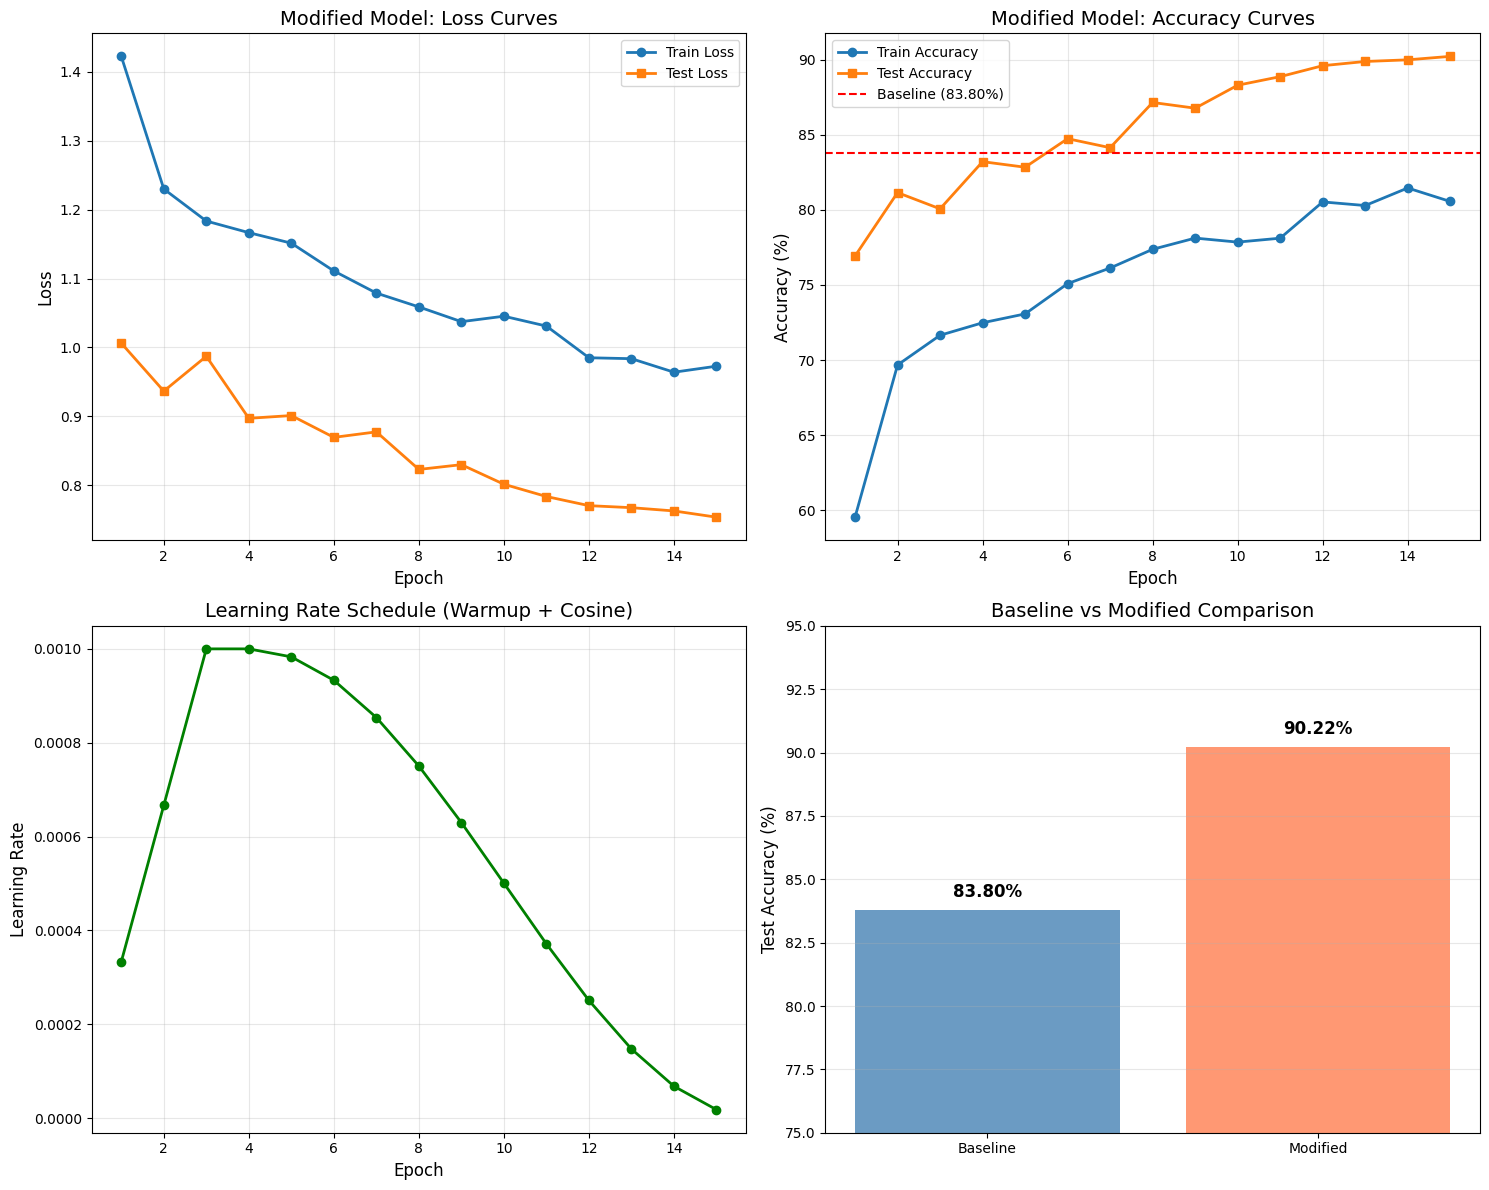


Results Summary:
Baseline:  83.80%
Modified:  90.22%
Change:    +6.42%


In [11]:
# Plot comprehensive results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss
axes[0, 0].plot(range(1, num_epochs+1), train_losses, 'o-', label='Train Loss', linewidth=2)
axes[0, 0].plot(range(1, num_epochs+1), test_losses, 's-', label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Modified Model: Loss Curves', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(range(1, num_epochs+1), train_accs, 'o-', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(range(1, num_epochs+1), test_accs, 's-', label='Test Accuracy', linewidth=2)
axes[0, 1].axhline(y=83.80, color='r', linestyle='--', label='Baseline (83.80%)')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Modified Model: Accuracy Curves', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 0].plot(range(1, num_epochs+1), learning_rates, 'o-', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule (Warmup + Cosine)', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Comparison bar chart
models = ['Baseline', 'Modified']
accuracies = [83.80, test_accs[-1]]
colors = ['steelblue', 'coral']
axes[1, 1].bar(models, accuracies, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Baseline vs Modified Comparison', fontsize=14)
axes[1, 1].set_ylim([75, 95])
for i, v in enumerate(accuracies):
    axes[1, 1].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('modified_model_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResults Summary:")
print(f"Baseline:  83.80%")
print(f"Modified:  {test_accs[-1]:.2f}%")
print(f"Change:    {'+' if test_accs[-1] > 83.80 else ''}{test_accs[-1] - 83.80:.2f}%")

In [20]:
# Save modified model
torch.save(model.state_dict(), 'modified_vit_model.pth')
print("Modified model saved")

# Save history
import pickle
history = {
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'learning_rates': learning_rates
}
with open('modified_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("Training history saved")

Modified model saved
Training history saved
